<a href="https://colab.research.google.com/github/IsaacGSolis/Mineria-de-Datos-IEGS/blob/main/KMeansE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# 1 Crear dataframe con los datos
data={
    'compras_mes':[1, 2, 1.5, 10, 12, 11, 4, 5, 6],
    'gasto_mensual':[2, 3, 2.5, 9, 11, 10, 5, 6, 7]
}
df=pd.DataFrame(data)
df

,compras_mes,gasto_mensual
0,1.0,2.0
1,2.0,3.0
2,1.5,2.5
3,10.0,9.0
4,12.0,11.0
5,11.0,10.0
6,4.0,5.0
7,5.0,6.0
8,6.0,7.0


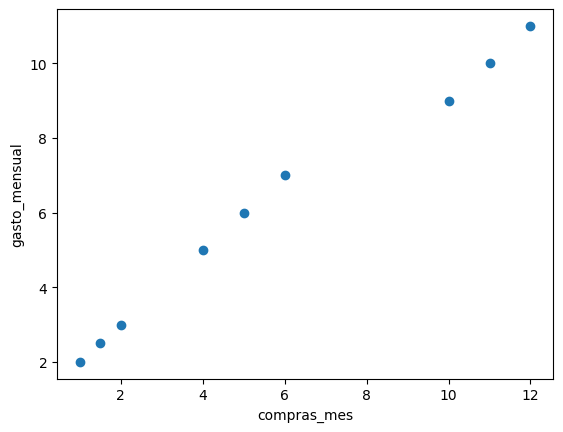

In [3]:
#2 Graficar los puntos (sin cluster)
plt.scatter(df['compras_mes'], df['gasto_mensual'])
plt.xlabel('compras_mes')
plt.ylabel('gasto_mensual')
plt.show()

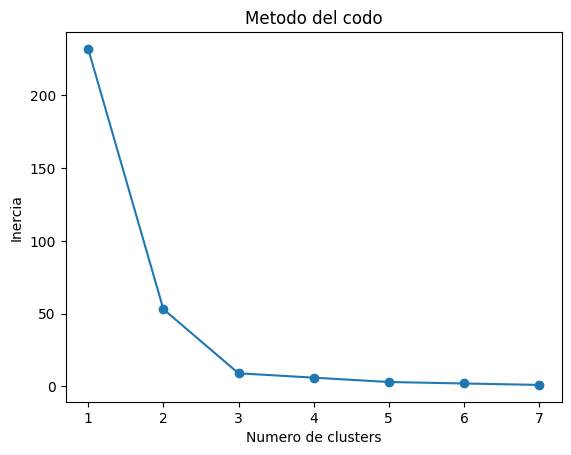

In [4]:
#3 Metodo del codo para encontrar k optimo
X=df[['compras_mes', 'gasto_mensual']].values
inercias=[]
for k in range(1, 8):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

#Graficar el metodo del codo
plt.plot(range(1, 8), inercias, marker='o')
plt.xlabel('Numero de clusters')
plt.ylabel('Inercia')
plt.title('Metodo del codo')
plt.show()

In [5]:
#4 Aplicamos kmeans con K=3
kmeans=KMeans(n_clusters=3, random_state=42)
df['cluster']=kmeans.fit_predict(X)
df

,compras_mes,gasto_mensual,cluster
0,1.0,2.0,1
1,2.0,3.0,1
2,1.5,2.5,1
3,10.0,9.0,2
4,12.0,11.0,2
5,11.0,10.0,2
6,4.0,5.0,0
7,5.0,6.0,0
8,6.0,7.0,0


In [6]:
#5 Mostrar Clusters
centroides=kmeans.cluster_centers_
centroides

array([[ 5. ,  6. ],
       [ 1.5,  2.5],
       [11. , 10. ]])

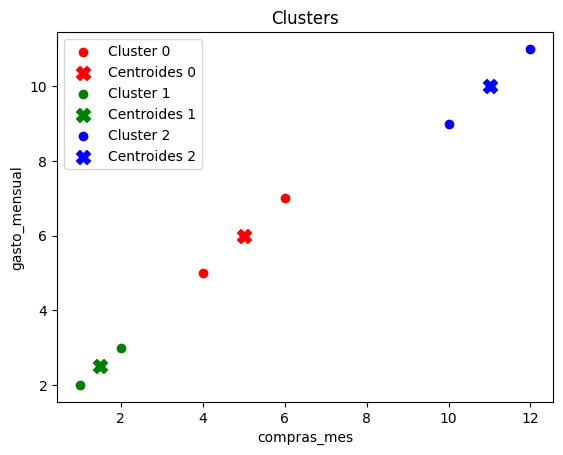

In [7]:
#6 Graficar clusters
colores=['red', 'green', 'blue']
for i in range(3):
    cluster=df[df['cluster']==i]
    plt.scatter(cluster['compras_mes'], cluster['gasto_mensual'], color=colores[i], label=f'Cluster {i}')
    plt.scatter(centroides[i, 0], centroides[i, 1], c=colores[i], marker='X',s=100,label=f'Centroides {i}')
plt.xlabel('compras_mes')
plt.ylabel('gasto_mensual')
plt.title('Clusters')
plt.legend()
plt.show()

**¿Qué tipo de clientes representa cada grupo?**

Grupo 1 (Cluster 0) serian clientes poco frecuentes, consumen poco y gastan poco.

Grupo 2 (Cluster 1) Serian clientes frecuentes, consumo y gasto medio.

Grupo 3 (Cluster 2) Serian clientes mayoristas, consumo y gasto en grandes cantidades.